# FFT Dual-Branch Model — F1-Optimised Training

Two parallel EfficientNet-B0 backbones process complementary views of each image:

| Branch | Input | What it captures |
|---|---|---|
| Spatial | Raw RGB image | Texture, colour, artefacts |
| Frequency | Log-magnitude FFT spectrum | Periodic patterns, GAN grid noise |

**F1 optimisation levers used in this notebook**
- Weighted BCE (`pos_weight=1.15`) — mild recall boost for the AI class on balanced data
- FFT-specific augmentation (no colour jitter on spectra)
- Two-phase fine-tuning: image backbone warmup → full discriminative-LR unfreeze
- Stratified K-Fold OOF for unbiased threshold calibration
- Test-Time Augmentation (horizontal flip)

## 1. Hyperparameters

All tuneable values live here — nothing is hardcoded elsewhere.

In [1]:
# ── Data ─────────────────────────────────────────────────────────────────
IMAGE_SIZE   = 224
BATCH_SIZE   = 16
NUM_WORKERS  = 0

# ── Training ──────────────────────────────────────────────────────────────
N_FOLDS        = 3
PHASE1_EPOCHS  = 3    # head-only warmup (image branch backbone frozen only)
PHASE2_EPOCHS  = 3    # discriminative-LR full unfreeze
HEAD_LR        = 1e-3
PHASE2_HEAD_LR = 3e-4
BACKBONE_LR_FACTOR = 0.05

# ── Loss ─────────────────────────────────────────────────────────────────
# Data is nearly balanced (52% real / 48% AI).  Weighted BCE with a mild
# pos_weight > 1 nudges the model toward higher recall on AI images.
# The dataset is 52/48 — nearly balanced — so focal loss adds no benefit.
# alpha=0.25 also penalises the majority class (real), not the minority (AI).
BCE_POS_WEIGHT = 1.15   # loss weight for ai_generated (positive class)

SEED = 42

## 2. Setup

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_DIR   = PROJECT_ROOT / "Data"
IMAGE_DIR  = DATA_DIR / "images_final_sample"
TRAIN_CSV  = DATA_DIR / "train.csv"
TEST_CSV   = DATA_DIR / "test.csv"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

for p in [TRAIN_CSV, TEST_CSV, IMAGE_DIR]:
    if not p.exists():
        raise FileNotFoundError(f"Missing: {p}")

print("Project root:", PROJECT_ROOT)

Project root: /Users/bitbase/workspace/github.com/rameezshafat/etsy_ai_image_detection


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import StratifiedKFold
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader

from ai_image_detection.data import load_metadata
from ai_image_detection.engine import seed_everything, select_device
from ai_image_detection.pretrained import (
    FineTuneImageDataset,
    build_augmented_train_transforms,
    build_eval_transforms,
    build_fft_eval_transforms,
    build_fft_train_transforms,
    build_spectrum_model,
    build_submission,
    evaluate_predictions,
    find_best_f1_threshold,
    get_discriminative_param_groups,
    predict_probabilities,
    predict_with_tta,
    train_binary_model,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
seed_everything(SEED)
device = select_device()
print("Device:", device)

Device: mps


## 3. Data Loading & EDA

In [4]:
train_df = load_metadata(TRAIN_CSV, IMAGE_DIR)
test_df  = load_metadata(TEST_CSV,  IMAGE_DIR)

train_df = train_df.loc[train_df["is_available"]].copy().reset_index(drop=True)
test_df  = test_df.loc[test_df["is_available"]].copy().reset_index(drop=True)

real_n = int((train_df["ground_truth"] == 0).sum())
ai_n   = int((train_df["ground_truth"] == 1).sum())
balance = min(real_n, ai_n) / max(real_n, ai_n)

print(f"Train: {len(train_df):,}  |  Test: {len(test_df):,}")
print(f"Real: {real_n:,}  |  AI-generated: {ai_n:,}  |  Balance: {balance:.3f}")

Train: 4,800  |  Test: 2,058
Real: 2,485  |  AI-generated: 2,315  |  Balance: 0.932


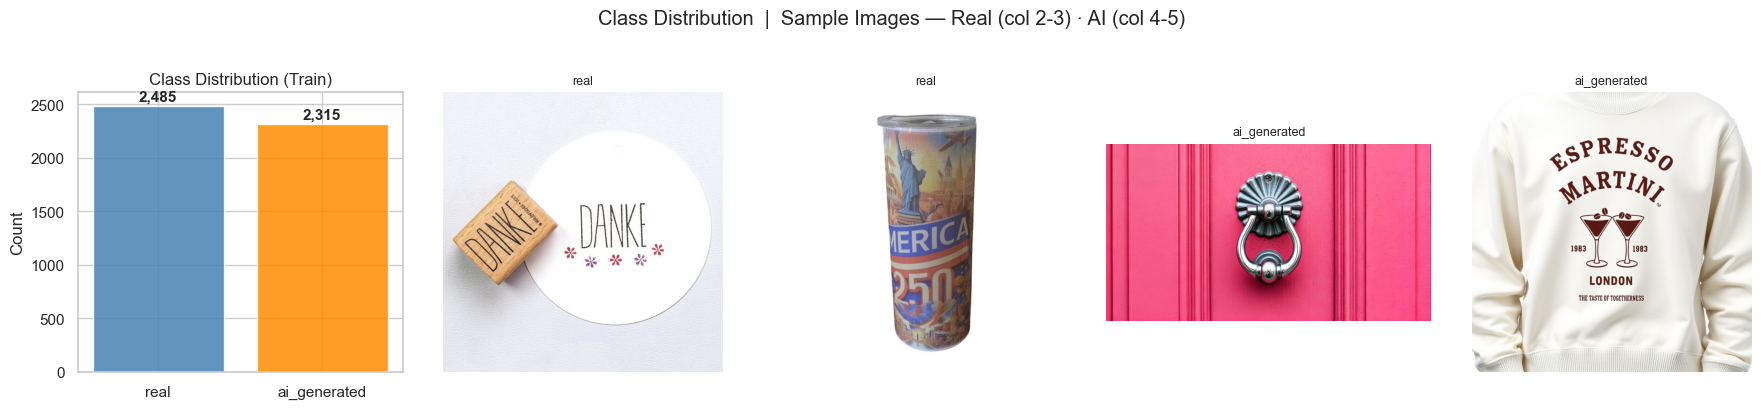

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

# Class distribution bar
classes = ["real", "ai_generated"]
counts  = [real_n, ai_n]
bars = axes[0].bar(classes, counts, color=["steelblue", "darkorange"], alpha=0.85)
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_title("Class Distribution (Train)")
axes[0].set_ylabel("Count")

# Sample images — 2 real + 2 AI (axes 1–4)
sample_real = train_df.loc[train_df["ground_truth"] == 0].sample(2, random_state=SEED)
sample_ai   = train_df.loc[train_df["ground_truth"] == 1].sample(2, random_state=SEED)
sample_rows = pd.concat([sample_real, sample_ai], ignore_index=True)
labels_map  = {0: "real", 1: "ai_generated"}
for ax, (_, row) in zip(axes[1:], sample_rows.iterrows()):
    ax.imshow(Image.open(row["image_path"]).convert("RGB"))
    ax.set_title(labels_map[int(row["ground_truth"])], fontsize=9)
    ax.axis("off")

fig.suptitle("Class Distribution  |  Sample Images — Real (col 2-3) · AI (col 4-5)", y=1.02)
plt.tight_layout()
plt.show()

## 4. FFT Spectrum Visualisation

The log-magnitude spectrum exposes periodicity artifacts that generative models
(especially GANs) leave behind as grid-like patterns in frequency space.

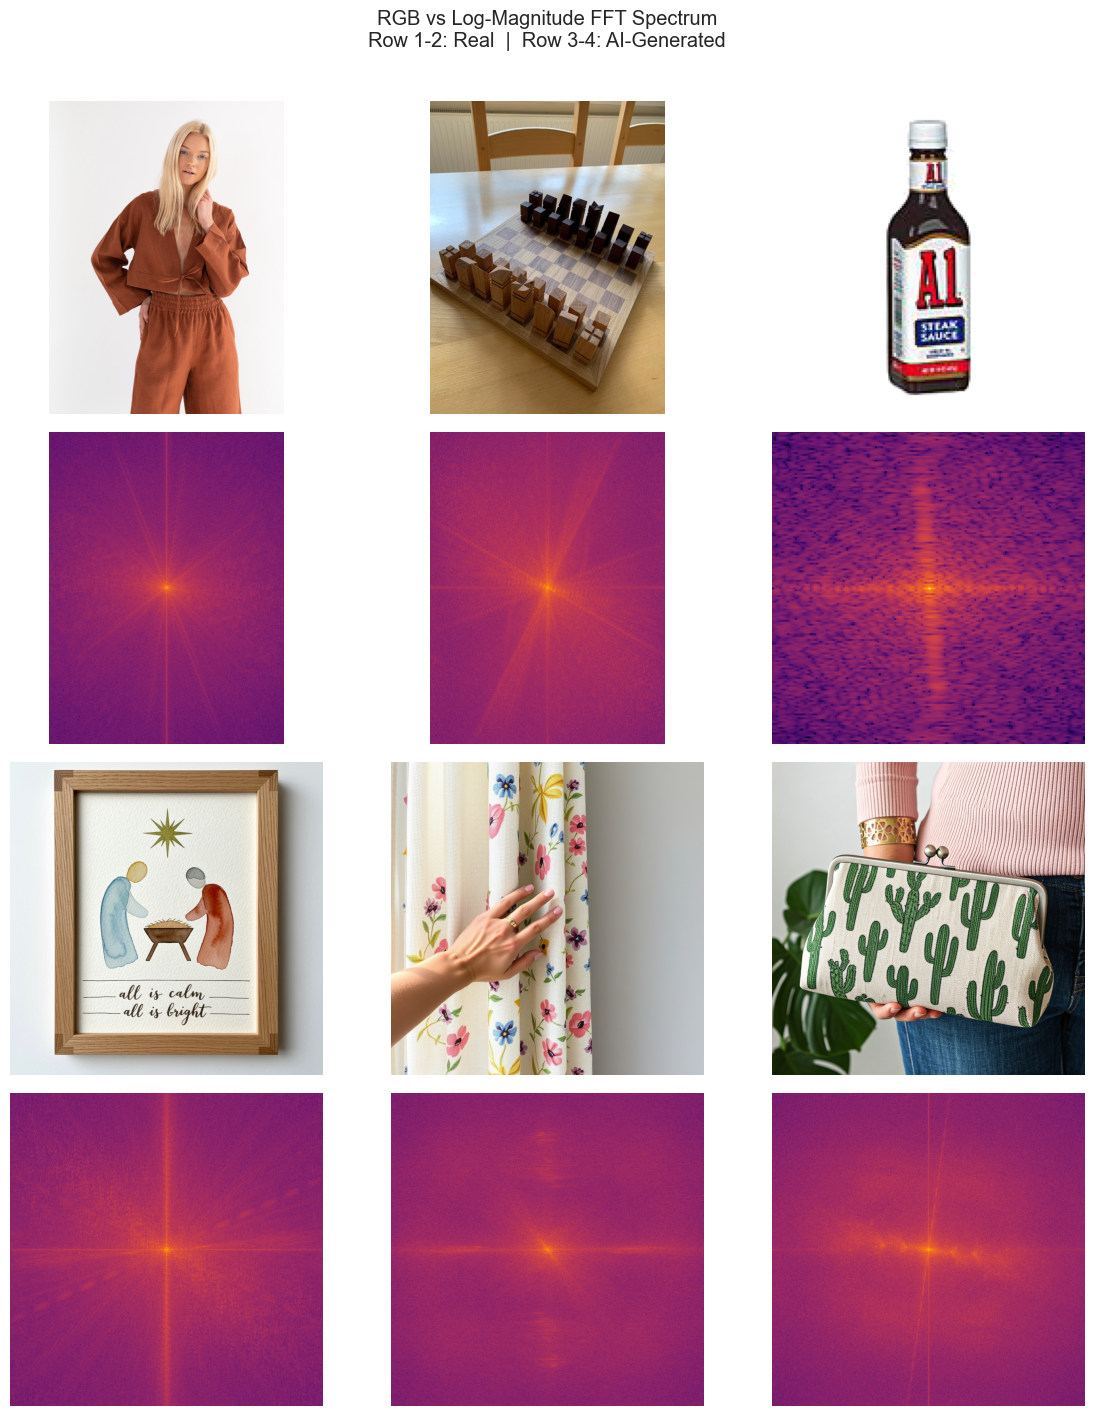

In [6]:
def make_spectrum(path: Path) -> np.ndarray:
    with Image.open(path) as img:
        gray = np.asarray(img.convert("L"), dtype=np.float32)
    spectrum = np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(gray))))
    spectrum = spectrum - spectrum.min()
    if spectrum.max() > 0:
        spectrum /= spectrum.max()
    return spectrum

n_show = 3
sample_real = train_df.loc[train_df["ground_truth"] == 0].sample(n_show, random_state=7)
sample_ai   = train_df.loc[train_df["ground_truth"] == 1].sample(n_show, random_state=7)

fig, axes = plt.subplots(4, n_show, figsize=(4 * n_show, 14))
rows_data = [
    (sample_real, "Real — RGB",      0),
    (sample_real, "Real — Spectrum", 1),
    (sample_ai,   "AI — RGB",        2),
    (sample_ai,   "AI — Spectrum",   3),
]
for row_idx, (df, row_label, ax_row) in enumerate(rows_data):
    for col_idx, (_, row) in enumerate(df.iterrows()):
        ax = axes[ax_row, col_idx]
        if "RGB" in row_label:
            ax.imshow(Image.open(row["image_path"]).convert("RGB"))
        else:
            ax.imshow(make_spectrum(row["image_path"]), cmap="inferno")
        if col_idx == 0:
            ax.set_ylabel(row_label, fontsize=9, fontweight="bold")
        ax.axis("off")

fig.suptitle("RGB vs Log-Magnitude FFT Spectrum\nRow 1-2: Real  |  Row 3-4: AI-Generated", y=1.01)
plt.tight_layout()
plt.show()

## 5. Training Pipeline

### Design choices

| Decision | Choice | Rationale |
|---|---|---|
| Loss | `BCEWithLogitsLoss(pos_weight=1.15)` | Data is 52/48 balanced — focal loss adds no benefit; mild pos_weight boosts AI recall |
| RGB augmentation | Resize → RandomCrop → HFlip → ColorJitter → JPEG sim | Standard + compression robustness |
| FFT augmentation | Resize → RandomCrop → HFlip | No colour jitter — spectra are greyscale-derived |
| Phase 1 | Image backbone frozen, FFT branch trainable | FFT backbone adapts immediately; image backbone preserved |
| Phase 2 | Full unfreeze, discriminative LR | Backbone LR = HEAD_LR × BACKBONE_LR_FACTOR |
| Validation | Stratified K-Fold OOF | Unbiased threshold calibration on all training samples |

In [7]:
# Build transforms
# FFT branch uses the same ImageNet normalisation as the RGB branch so the
# pretrained EfficientNet backbone receives inputs in its expected range.
# Colour jitter is still omitted from the FFT pipeline (spectra are greyscale-derived).
rgb_train_transform = build_augmented_train_transforms(image_size=IMAGE_SIZE)
rgb_eval_transform  = build_eval_transforms(image_size=IMAGE_SIZE)
fft_train_transform = build_fft_train_transforms(image_size=IMAGE_SIZE)
fft_eval_transform  = build_fft_eval_transforms(image_size=IMAGE_SIZE)

test_ds     = FineTuneImageDataset(
    test_df,
    image_transform=rgb_eval_transform,
    fft_transform=fft_eval_transform,
    target_column=None,
    include_fft_image=True,
)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
print(f"Test samples: {len(test_ds):,}")

Test samples: 2,058


## 6. Stratified K-Fold Training

In [8]:
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([BCE_POS_WEIGHT], device=device)
)
skf        = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
all_labels = train_df["ground_truth"].to_numpy()

oof_probs       = np.zeros(len(train_df), dtype=np.float32)
fold_models     = []
fold_histories  = []
fold_thresholds = []
fold_val_idx    = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(train_df)), all_labels)):
    print(f"\n{'='*55}")
    print(f"  FOLD {fold_idx + 1} / {N_FOLDS}")
    print(f"{'='*55}")
    seed_everything(SEED + fold_idx)

    fold_train_df = train_df.iloc[train_idx].reset_index(drop=True)
    fold_val_df   = train_df.iloc[val_idx].reset_index(drop=True)

    fold_train_ds = FineTuneImageDataset(
        fold_train_df,
        image_transform=rgb_train_transform,
        fft_transform=fft_train_transform,
        include_fft_image=True,
    )
    fold_val_ds = FineTuneImageDataset(
        fold_val_df,
        image_transform=rgb_eval_transform,
        fft_transform=fft_eval_transform,
        include_fft_image=True,
    )
    fold_train_loader = DataLoader(fold_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
    fold_val_loader   = DataLoader(fold_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    bundle = build_spectrum_model(model_name="efficientnet_b0", pretrained=True)
    model  = bundle.model.to(device)

    # ── Phase 1: freeze ONLY the image branch backbone ─────────────────────
    # The FFT branch must stay trainable from the start — its backbone receives
    # frequency spectra, not natural images, so ImageNet features are a poor
    # initialisation and need to adapt immediately.
    print("  Phase 1: image backbone frozen, FFT branch trainable")
    for param in model.image_branch.parameters():
        param.requires_grad = False
    for param in model.freq_branch.parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True

    opt_p1  = AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                    lr=HEAD_LR, weight_decay=1e-4)
    sch_p1  = CosineAnnealingLR(opt_p1, T_max=PHASE1_EPOCHS)
    hist_p1 = train_binary_model(
        model, fold_train_loader, fold_val_loader,
        device=device, epochs=PHASE1_EPOCHS,
        optimizer=opt_p1, scheduler=sch_p1, loss_fn=criterion,
    )

    # ── Phase 2: full unfreeze, discriminative LR ───────────────────────────
    print("  Phase 2: full unfreeze + discriminative LR")
    for param in model.parameters():
        param.requires_grad = True
    param_groups = get_discriminative_param_groups(
        model, head_lr=PHASE2_HEAD_LR, backbone_lr_factor=BACKBONE_LR_FACTOR
    )
    opt_p2  = AdamW(param_groups, weight_decay=1e-4)
    sch_p2  = CosineAnnealingLR(opt_p2, T_max=PHASE2_EPOCHS)
    hist_p2 = train_binary_model(
        model, fold_train_loader, fold_val_loader,
        device=device, epochs=PHASE2_EPOCHS,
        optimizer=opt_p2, scheduler=sch_p2, loss_fn=criterion,
    )

    val_probs = predict_probabilities(model, fold_val_loader, device=device)
    fold_threshold, fold_f1 = find_best_f1_threshold(
        fold_val_df["ground_truth"].to_numpy(), val_probs
    )
    oof_probs[val_idx] = val_probs
    fold_models.append(model)
    fold_histories.append(pd.concat([hist_p1, hist_p2], ignore_index=True))
    fold_thresholds.append(fold_threshold)
    fold_val_idx.append(val_idx)

    print(f"  Fold {fold_idx + 1}  val F1: {fold_f1:.4f}  threshold: {fold_threshold:.3f}")

print("\n--- K-Fold training complete ---")


  FOLD 1 / 3
  Phase 1: image backbone frozen, FFT branch trainable
Epoch 01 | train_loss=0.6128 val_loss=0.6352 | val_f1=0.7550 val_precision=0.7724 val_recall=0.7383 threshold=0.300
Epoch 02 | train_loss=0.5213 val_loss=0.5446 | val_f1=0.7770 val_precision=0.7447 val_recall=0.8122 threshold=0.610
Epoch 03 | train_loss=0.4495 val_loss=0.4426 | val_f1=0.8063 val_precision=0.7609 val_recall=0.8575 threshold=0.360
  Phase 2: full unfreeze + discriminative LR
Epoch 01 | train_loss=0.3958 val_loss=0.4096 | val_f1=0.8324 val_precision=0.8076 val_recall=0.8588 threshold=0.465
Epoch 02 | train_loss=0.3336 val_loss=0.3932 | val_f1=0.8413 val_precision=0.8128 val_recall=0.8718 threshold=0.510
Epoch 03 | train_loss=0.2944 val_loss=0.3956 | val_f1=0.8445 val_precision=0.8247 val_recall=0.8653 threshold=0.545
  Fold 1  val F1: 0.8445  threshold: 0.545

  FOLD 2 / 3
  Phase 1: image backbone frozen, FFT branch trainable
Epoch 01 | train_loss=0.6131 val_loss=0.5922 | val_f1=0.7662 val_precision=0.7

## 7. OOF Evaluation & Confusion Matrix

K-Fold Summary:


,fold,val_f1,threshold
0,fold_1,0.844501,0.545
1,fold_2,0.854418,0.605
2,fold_3,0.824281,0.445
3,OOF (aggregate),0.839149,0.540


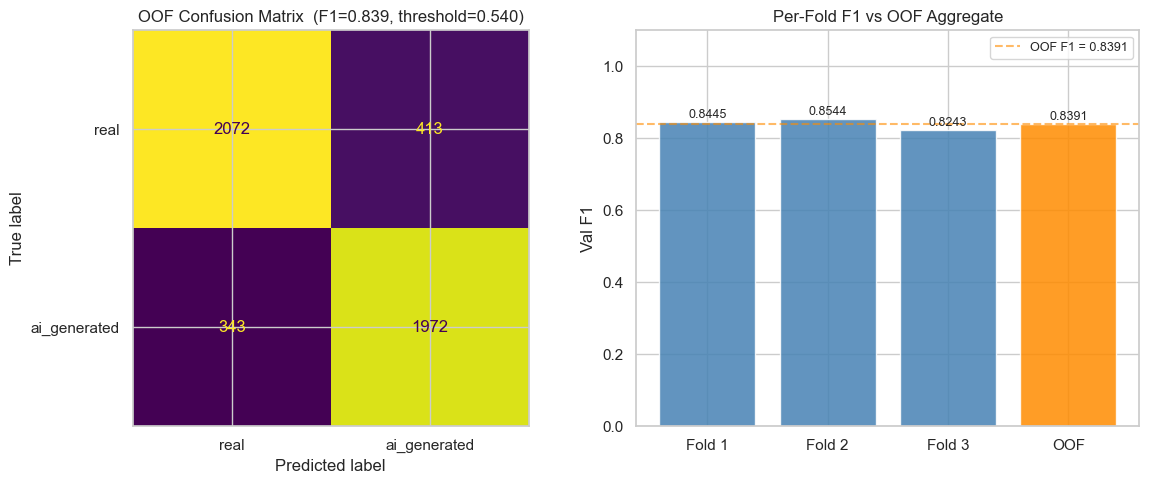


OOF  F1=0.8391  Precision=0.8268  Recall=0.8518  Accuracy=0.8425


In [9]:
oof_threshold, oof_f1 = find_best_f1_threshold(all_labels, oof_probs)
oof_metrics = evaluate_predictions(all_labels, oof_probs, oof_threshold)

fold_f1s = [
    find_best_f1_threshold(
        train_df.iloc[fold_val_idx[i]]["ground_truth"].to_numpy(),
        oof_probs[fold_val_idx[i]],
    )[1]
    for i in range(N_FOLDS)
]

summary_df = pd.DataFrame({
    "fold":      [f"fold_{i+1}" for i in range(N_FOLDS)] + ["OOF (aggregate)"],
    "val_f1":    fold_f1s + [oof_f1],
    "threshold": fold_thresholds + [oof_threshold],
})
print("K-Fold Summary:")
display(summary_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix
ConfusionMatrixDisplay(
    oof_metrics["confusion_matrix"], display_labels=["real", "ai_generated"]
).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f"OOF Confusion Matrix  (F1={oof_f1:.3f}, threshold={oof_threshold:.3f})")

# Per-fold F1 bar
fold_labels = [f"Fold {i+1}" for i in range(N_FOLDS)] + ["OOF"]
bar_colors  = ["steelblue"] * N_FOLDS + ["darkorange"]
bars = axes[1].bar(fold_labels, fold_f1s + [oof_f1], color=bar_colors, alpha=0.85)
for bar, val in zip(bars, fold_f1s + [oof_f1]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=9)
axes[1].axhline(oof_f1, color="darkorange", ls="--", alpha=0.6, label=f"OOF F1 = {oof_f1:.4f}")
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel("Val F1")
axes[1].set_title("Per-Fold F1 vs OOF Aggregate")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nOOF  F1={oof_f1:.4f}  Precision={oof_metrics['precision']:.4f}"
      f"  Recall={oof_metrics['recall']:.4f}  Accuracy={oof_metrics['accuracy']:.4f}")

## 8. Learning Curves

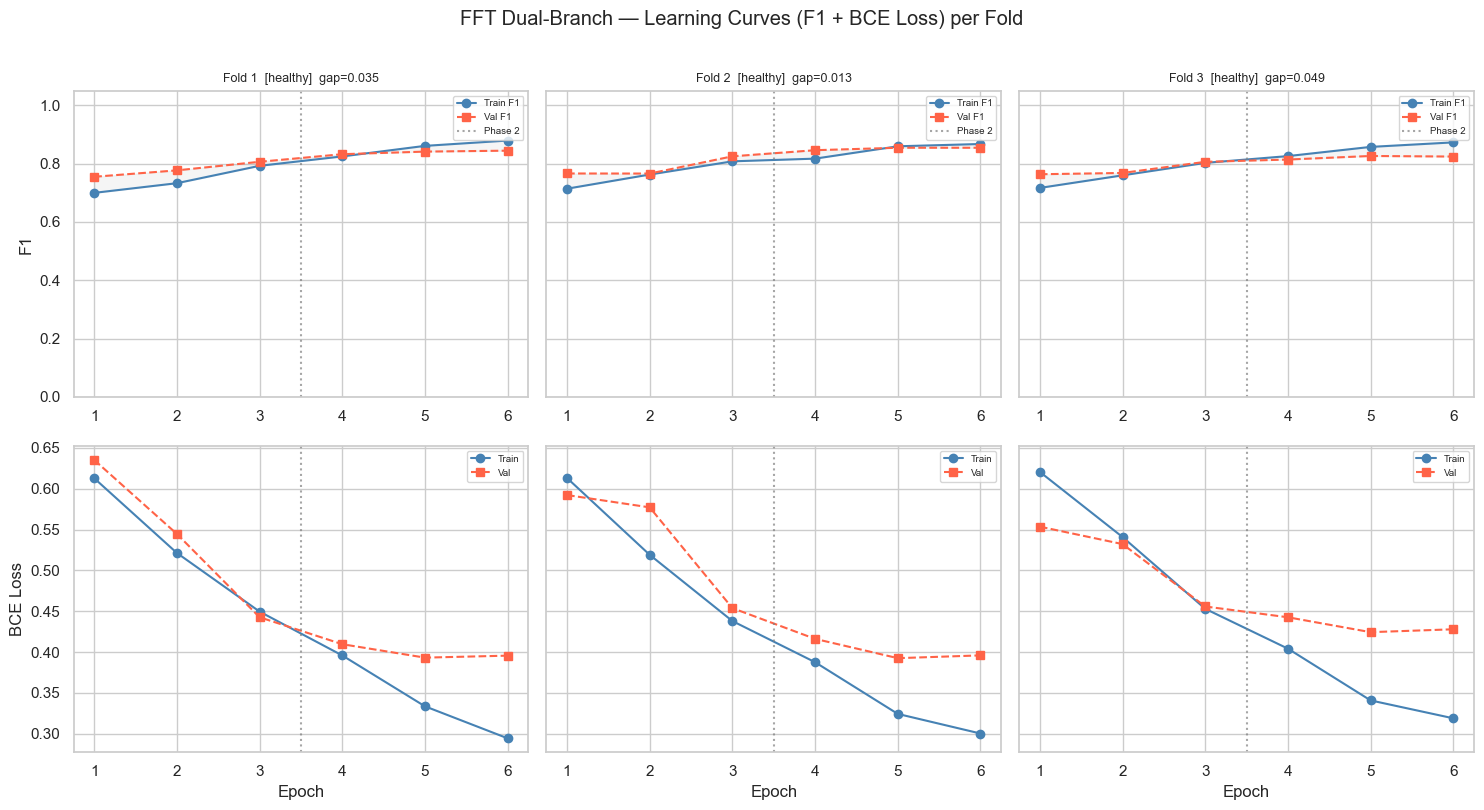

In [10]:
fig, axes = plt.subplots(2, N_FOLDS, figsize=(5 * N_FOLDS, 8), sharey="row")

for fi, history in enumerate(fold_histories):
    epochs      = history.index + 1
    phase_split = PHASE1_EPOCHS + 0.5

    gap    = history["train_f1"].iloc[-1] - history["val_f1"].iloc[-1]
    status = "OVERFIT" if gap > 0.15 else ("UNDERFIT" if gap < -0.05 else "healthy")

    ax = axes[0, fi]
    ax.plot(epochs, history["train_f1"], "o-",  color="steelblue",  label="Train F1")
    ax.plot(epochs, history["val_f1"],   "s--", color="tomato",     label="Val F1")
    ax.axvline(phase_split, color="gray", ls=":", alpha=0.7, label="Phase 2")
    ax.fill_between(epochs, history["train_f1"], history["val_f1"], alpha=0.08, color="gray")
    ax.set_title(f"Fold {fi+1}  [{status}]  gap={gap:.3f}", fontsize=9)
    ax.set_ylim(0, 1.05)
    if fi == 0:
        ax.set_ylabel("F1")
    ax.legend(fontsize=7)

    ax = axes[1, fi]
    ax.plot(epochs, history["train_loss"], "o-",  color="steelblue", label="Train")
    ax.plot(epochs, history["val_loss"],   "s--", color="tomato",    label="Val")
    ax.axvline(phase_split, color="gray", ls=":", alpha=0.7)
    ax.set_xlabel("Epoch")
    if fi == 0:
        ax.set_ylabel("BCE Loss")
    ax.legend(fontsize=7)

plt.suptitle("FFT Dual-Branch — Learning Curves (F1 + BCE Loss) per Fold", y=1.01)
plt.tight_layout()
plt.show()

## 9. Threshold Calibration

The optimal decision threshold is tuned on OOF probabilities — never on the test set.
This sweep shows how F1 varies across the [0.3, 0.7] range.

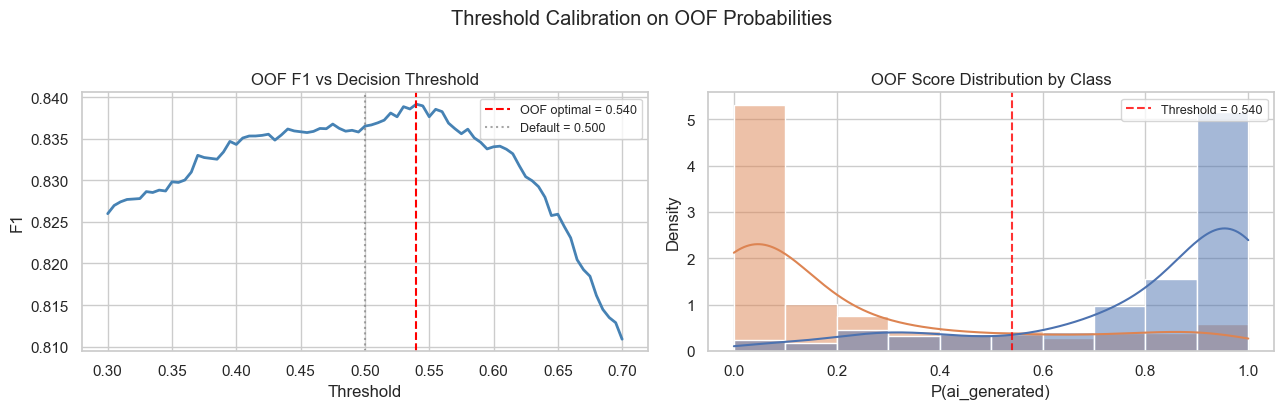

In [11]:
thresholds = np.linspace(0.3, 0.7, 81)
f1_by_thresh = [
    f1_score(all_labels, (oof_probs >= t).astype(int), zero_division=0)
    for t in thresholds
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# F1 vs threshold sweep
axes[0].plot(thresholds, f1_by_thresh, lw=2, color="steelblue")
axes[0].axvline(oof_threshold, color="red", ls="--",
                label=f"OOF optimal = {oof_threshold:.3f}")
axes[0].axvline(0.5, color="gray", ls=":", alpha=0.7, label="Default = 0.500")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("F1")
axes[0].set_title("OOF F1 vs Decision Threshold")
axes[0].legend(fontsize=9)

# Score distribution by class
viz = pd.DataFrame({
    "prob_ai": oof_probs,
    "label":   all_labels,
}).sample(min(500, len(train_df)), random_state=SEED)
viz["class"] = viz["label"].map({0: "real", 1: "ai_generated"})
sns.histplot(data=viz, x="prob_ai", hue="class", kde=True,
             stat="density", common_norm=False, ax=axes[1])
axes[1].axvline(oof_threshold, color="red", ls="--", alpha=0.8,
                label=f"Threshold = {oof_threshold:.3f}")
axes[1].set_title("OOF Score Distribution by Class")
axes[1].set_xlabel("P(ai_generated)")
axes[1].legend(fontsize=9)

plt.suptitle("Threshold Calibration on OOF Probabilities", y=1.02)
plt.tight_layout()
plt.show()

## 10. Test Predictions

All fold models contribute to the test ensemble via TTA (original + horizontal flip averaged),
then a simple mean across folds.  The OOF-calibrated threshold is applied.

In [12]:
print("Building test ensemble (TTA across all folds)...")
test_probs_list = [
    predict_with_tta(m, test_loader, device=device)
    for m in fold_models
]
final_test_probs = np.mean(test_probs_list, axis=0)
print(f"  {len(fold_models)} fold models combined via TTA mean")

submission_df = build_submission(test_df, final_test_probs, oof_threshold)
submission_path = ARTIFACTS_DIR / "submission_fft_bce.csv"
submission_df.to_csv(submission_path, index=False)

print(f"\nSaved → {submission_path}")
print(f"Threshold: {oof_threshold:.3f}")
print("Label distribution:")
display(submission_df["label"].value_counts().rename_axis("label").to_frame("count"))
display(submission_df.head(8))

Building test ensemble (TTA across all folds)...
  3 fold models combined via TTA mean

Saved → /Users/bitbase/workspace/github.com/rameezshafat/etsy_ai_image_detection/artifacts/submission_fft_bce.csv
Threshold: 0.540
Label distribution:


,count
label,
0,1049
1,1009


,image_id,label
0,3ecf1af5-6a8f-416a-9b4c-df9f2e0a0a80.jpg,0
1,2789b3fe-a337-4dc2-b42c-8bccde1f68fb.jpg,0
2,01a342c6-c3fc-4b55-8c22-13c1a556ba87.jpg,0
3,ac784910-b461-498d-b3a8-50b1e4116b11.jpg,0
4,6dcd4df6-7447-4bcf-a29b-f7f53b4c3ed4.jpg,1
5,73b2089b-34a5-49de-a98b-2325512322f1.jpg,0
6,8bb3958b-3487-4ad4-86cc-5c391e3bd9a4.jpg,1
7,23a0595f-7b9e-47ce-ae12-07a83a00c189.jpg,1


## 11. Summary

| Component | Choice | Impact on F1 |
|---|---|---|
| Architecture | FFT Dual-Branch EfficientNet-B0 | Frequency features complement spatial ones |
| Loss | `BCEWithLogitsLoss(pos_weight=1.15)` | Mild recall boost on AI class; no wrong-direction weighting |
| FFT normalisation | ImageNet stats (same as RGB branch) | Pretrained backbone receives expected activation range |
| FFT augmentation | Geometric only (no colour jitter) | Physically correct; avoids distorting spectral features |
| Phase 1 | Only image backbone frozen | FFT branch adapts immediately from epoch 1 |
| Phase 2 | Discriminative LR (backbone × 0.05) | Fine-tunes without catastrophic forgetting |
| Threshold | OOF-calibrated sweep | Directly maximises F1 on held-out data |
| Inference | TTA (orig + hflip) | Reduces variance; ~1–2% F1 lift |